In [2]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# ToolNode

We will re-use tools we created before:

In [5]:
import math
import numexpr as ne
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

@tool
def calculator(expression: str) -> str:
    """Calculates a single mathematical expression, incl. complex numbers.

    Always add * to operations, examples:
        73i -> 73*i
        7pi**2 -> 7*pi**2
    """
    math_constants = {"pi": math.pi, "i": 1j, "e": math.exp}
    result = ne.evaluate(expression.strip(), local_dict=math_constants)
    return str(result)

llm_with_tools = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools([search, calculator])

We will build our own ReACT agent, but this time we will use a `ToolNode` to execute tool calls automatically:

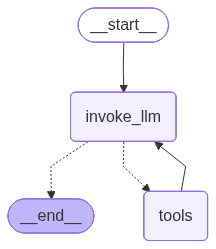

In [7]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState, StateGraph, START, END

def invoke_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("invoke_llm", invoke_llm)
builder.add_node("tools", ToolNode([search, calculator]))

builder.add_edge(START, "invoke_llm")
builder.add_conditional_edges("invoke_llm", tools_condition)
builder.add_edge("tools", "invoke_llm")
builder.add_edge("tools", END)
builder.add_edge("invoke_llm", END)

graph = builder.compile()

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langchain_core.messages import HumanMessage

for e in graph.stream({"messages": HumanMessage("How much is 2+2")}):
    print(e)

{'invoke_llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'calculator', 'arguments': '{"expression": "2+2"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b5f0c-3b7e-7dc0-a522-a6d450a32013-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '2+2'}, 'id': '950ee287-1134-4c50-8407-5d80d797e20e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 149, 'output_tokens': 15, 'total_tokens': 164, 'input_token_details': {'cache_read': 0}})]}}
{'tools': {'messages': [ToolMessage(content='4', name='calculator', id='61ed5353-666b-4ef3-ae9a-e35574059384', tool_call_id='950ee287-1134-4c50-8407-5d80d797e20e')]}}
{'invoke_llm': {'messages': [AIMessage(content='2+2 is 4.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019b5f

Now we will look at examples how to use custom tools to easily extract dates from user input:

In [11]:
examples = [
    "I signed my contract 2 years ago",
    "I started the deal with your company in February last year",
    "Our contract started March 24th two years ago",
]

In [12]:
from datetime import date, timedelta

@tool
def get_date(year: int, month: int=1, day: int=1) -> date:
  """Returns a date object given year, month and day.

    Default month and day are 1 (January) and 1.
    Examples in YYY-MM-DD format:
      2023-07-27 -> date(2023, 7, 27)
      2022-12-15 -> date(2022, 12, 15)
      Math 2022 -> date(2022, 3)
      2021 -> date(2021)
  """
  return date(year, month, day).isoformat()

@tool
def time_difference(days: int = 0, weeks: int = 0, months: int = 0, years: int = 0) -> date:
  """Returns a date given a difference in days, weeks, months and years relative to the current date.

  By default, days weeks, months, and years are 0.
  Examples:
    two weeks ago -> time_difference(weeks=2)
    last_year -> time_difference(years=1)
  """
  dt = date.today() - timedelta(days=days, weeks=weeks)
  new_year = dt.year + (dt.month-months) // 12 - years
  new_month = (dt.month-months) % 12
  return dt.replace(year=new_year, month=new_month)

In [13]:
from langgraph.prebuilt import create_react_agent

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

agent = create_react_agent(
  llm,
  [get_date, time_difference],
  prompt="Extract the starting date of a contract. Current year is 2025."
)

for example in examples:
  result = agent.invoke({"messages": [HumanMessage(example)]})
  print(example, result["messages"][-1].content)


I signed my contract 2 years ago [{'type': 'text', 'text': 'Your contract started on 2023-01-01.', 'extras': {'signature': 'Cr4DAXLI2nyfz4Kt4AkfzOQya15ejNMeDREm9r+dperFfON6RKrmpl5C5oCGNyMk5GlQSCRHcRACUlWPG8Nkh8OMo1GgUOFqaq9/dZRFCj3Dsy7I1rnXGp+eDPVXoSuoLWHtM1+meFq6rpSnslQClrXzbZngIrCHrkI/i5w63cAQ2vRugGhvkr6/O5+M6gpcGebVNnkVnIkxB6UouKIV4yohKxORmkirySCSjjCc8ePwJvOxo9bavi5Av/pLYLg8gWgwdVJAvx2jlBEtlht9VMldPfSi18ysJuzv5iqnYzKSXz5jEtooy4Cgjbz5qOYloqo0UVXIWEssOvHWENELtUQFx+WDyx07otvsLGMUQB6x28Ld6qV95Vl/lBK5QRLsJyYQf57guUxMTWd6j4UKL0GOD5rlgcqOJToTYvkoLohuHprRUtUfLXK0dxSRh5VZKbU/KU0FKP8R+Vx1P6MBWUbqeat35Q0uu8b2P7XAoi9Rz1v4c7zrUC/oBJk4OlmL09buJ2N6NEnrPYa4PaIKaS7qgQe6+82xl3NFLhEdnT6pFSmcCc0OErDseUW8VYnnJdGH5GZYNIrgWPv2wv/Zmrw='}}]
I started the deal with your company in February last year The starting date of your contract was 2024-02-01.
Our contract started March 24th two years ago The contract started on 2023-03-24.


In [14]:
for e in agent.stream({"messages": [HumanMessage(examples[1])]}):
    print(e)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_date', 'arguments': '{"month": 2, "year": 2024}'}, '__gemini_function_call_thought_signatures__': {'15f14a58-41db-463d-af90-f5a1ed4e0a8c': 'CsUHAXLI2nwrJwYYaGKfGF/tmCjrKbZhTXzBcKF0u/f0yC3fSrx4sonfvFP+oEtoaXUQwHtDF1H5rig2pdWs9iJmYCrjp+ooikDpRaykCw67zfB6W0KMWwj9Yi1F1jszVFuagDotDK1ZhnS2Jdib+3DLViF8p2ata0W4/tnW4sBw3zTT/IpLqZrRt3Wz0PPPf72+Ev24ci1r9kw5CqblYai8K69Cy3qetN+7Ietvz/BsuJjwPTpMi8boCuDs8ijydCdJq/+BbLwKUQtvycxos4lM5lQAXdAnjydxTIAE62phVrnvE/FJO15dCKNn6ghU0QucxRjCIhYoSXFMKy2RLI788BMmNMz3OqGg48O9J1LI+Di43sydZBoLw7SCxbcO0EDjtWOp9TKtwrALIK0RTVO5ddrYjHbhyuRv8If2zG8/DqlDk/qCM8oIlRMwh/cduPGO66SnjeQBNLVcPrUncLWcUVuhD2k48Mv5XxHGDZBTcOsBOMilBICA8EJHnOrCWdI+VA3cOWh+dwXKrS7NLuZ2d/LtuaZ/ofWEmBt9LQndVVTm0spnNe85n1ERQuZQdWJeZ/eF0IHo8sq067dr4m3vc2ZRCXXZQQEFfAmQJ/IbFxuaJX6uWYG+yjoIkHXhF5C6a0Y5k0049xlfg7mkBCSDLmxMGicPgsMmXo2qz8ZN6nAYF/ZhEe/KvaBH3mxzuXWYSzdBVakfLc05O6PuNFbzFa4CNicemynNbdvFsGWYaCVV5AmpxCcxxXKq

We can also explore the answer the model produced to pass to a user:

In [15]:
result["messages"][-1].content

'The contract started on 2023-03-24.'